In [22]:
from forecast import AnalisadorSerieTemporalCompleto
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

In [23]:
df = pd.read_csv('../09_Matriculas_BR.csv')


📊 DADOS FALTANTES DETECTADOS
Quantidade: 533 (92.37%)
Método de interpolação: linear
✓ Interpolação concluída

SÉRIE TEMPORAL: value
Período: 1970-01-01 00:00:00 até 2018-01-01 00:00:00
Frequência: MS
Total de observações: 577
Treino: 461 | Teste: 116


INICIANDO ANÁLISE COMPLETA DE SÉRIE TEMPORAL

1. ANÁLISE EXPLORATÓRIA DE DADOS

ESTATÍSTICAS DESCRITIVAS
--------------------------------------------------
Média...................................      3185422.85
Mediana.................................      1716263.00
Desvio Padrão...........................      2525551.04
Coef. Variação..........................           79.28
Mínimo..................................       430473.00
Máximo..................................      8741996.00
Amplitude...............................      8311523.00
Q1 (25%)................................      1436287.00
Q3 (75%)................................      4922587.00
IQR.....................................      3486300.00
Assimetria.........

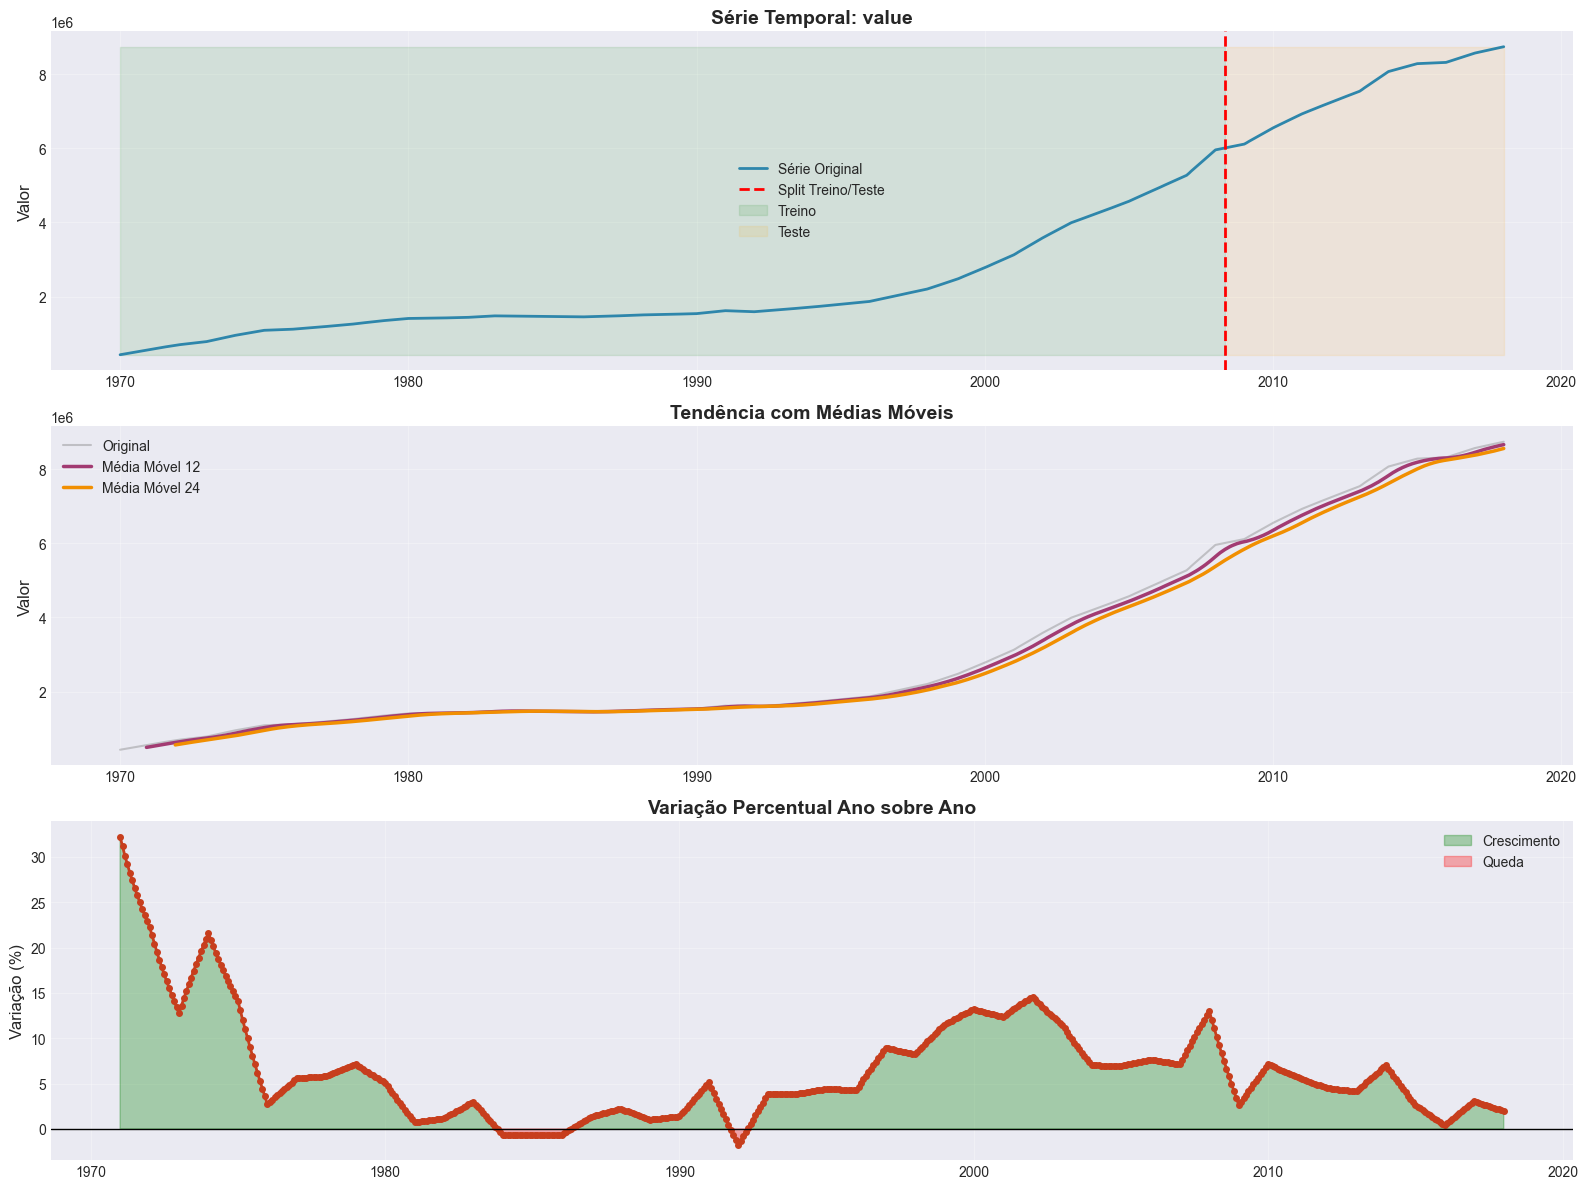

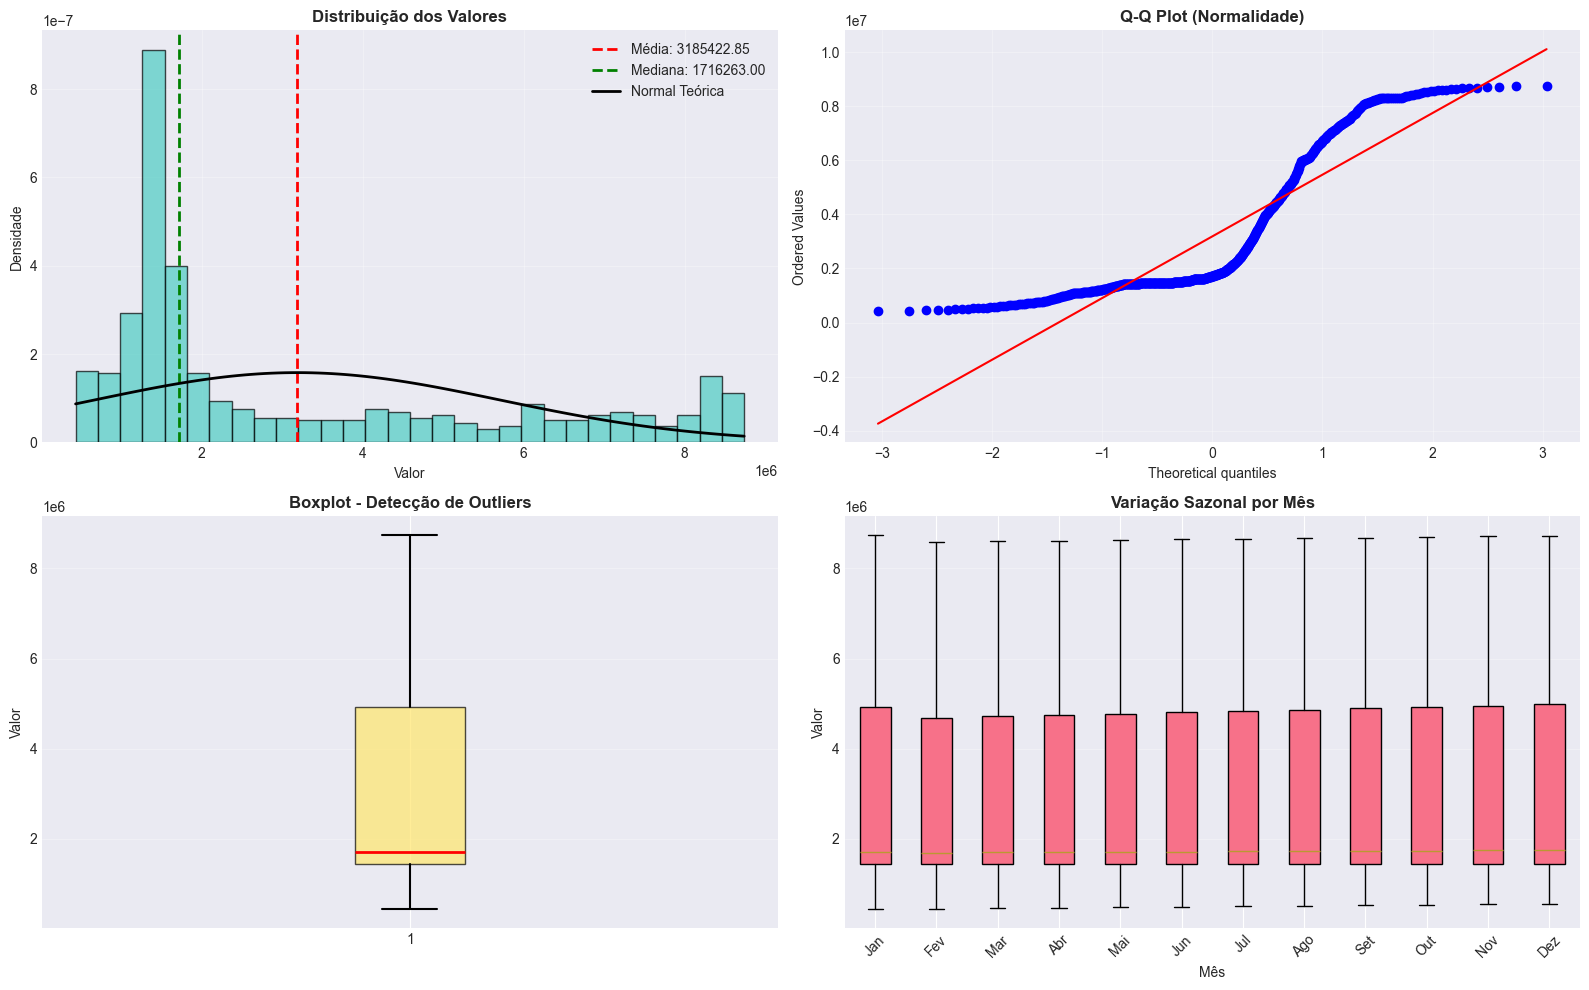

TESTE DE NORMALIDADE (Jarque-Bera)
Estatística: 97.6137
P-valor: 0.0000
Conclusão: Distribuição NÃO-NORMAL (α=0.05)

DETECÇÃO DE OUTLIERS
Método IQR: 0 outliers (0.00%)
Método Z-Score (>3): 0 outliers (0.00%)



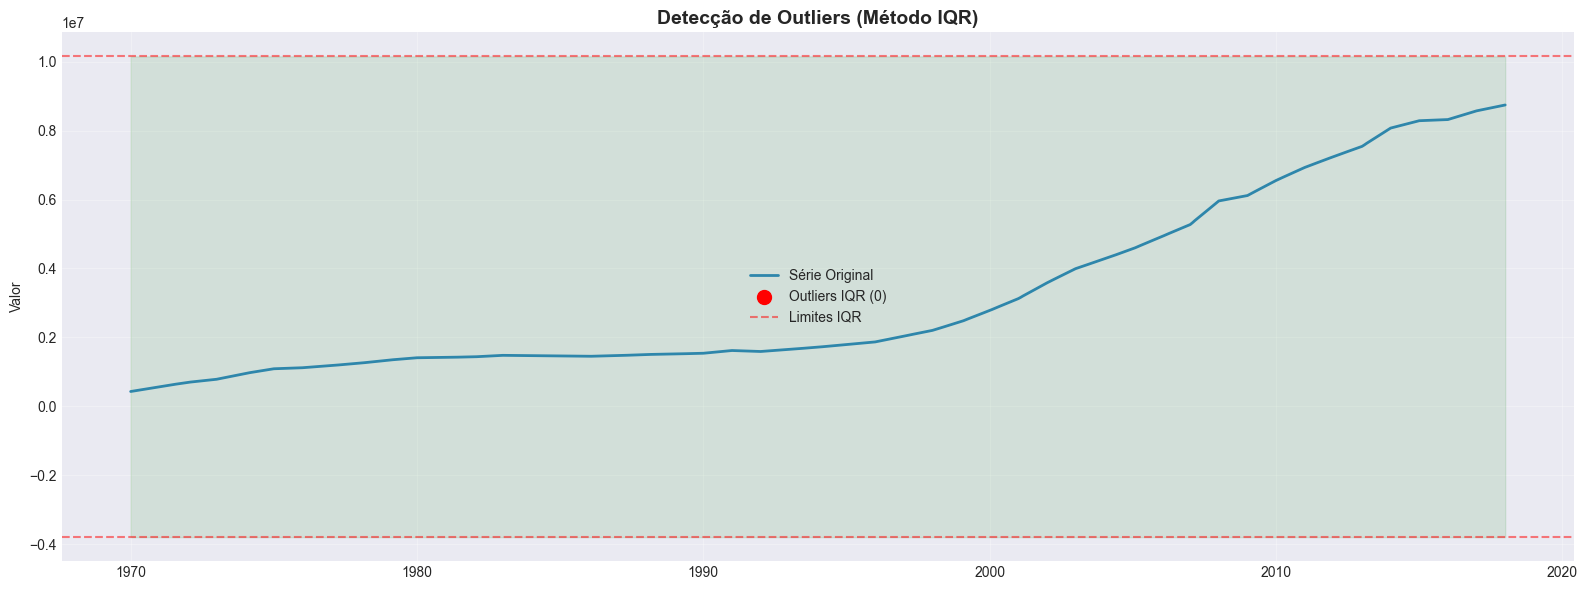


2. DECOMPOSIÇÃO SAZONAL



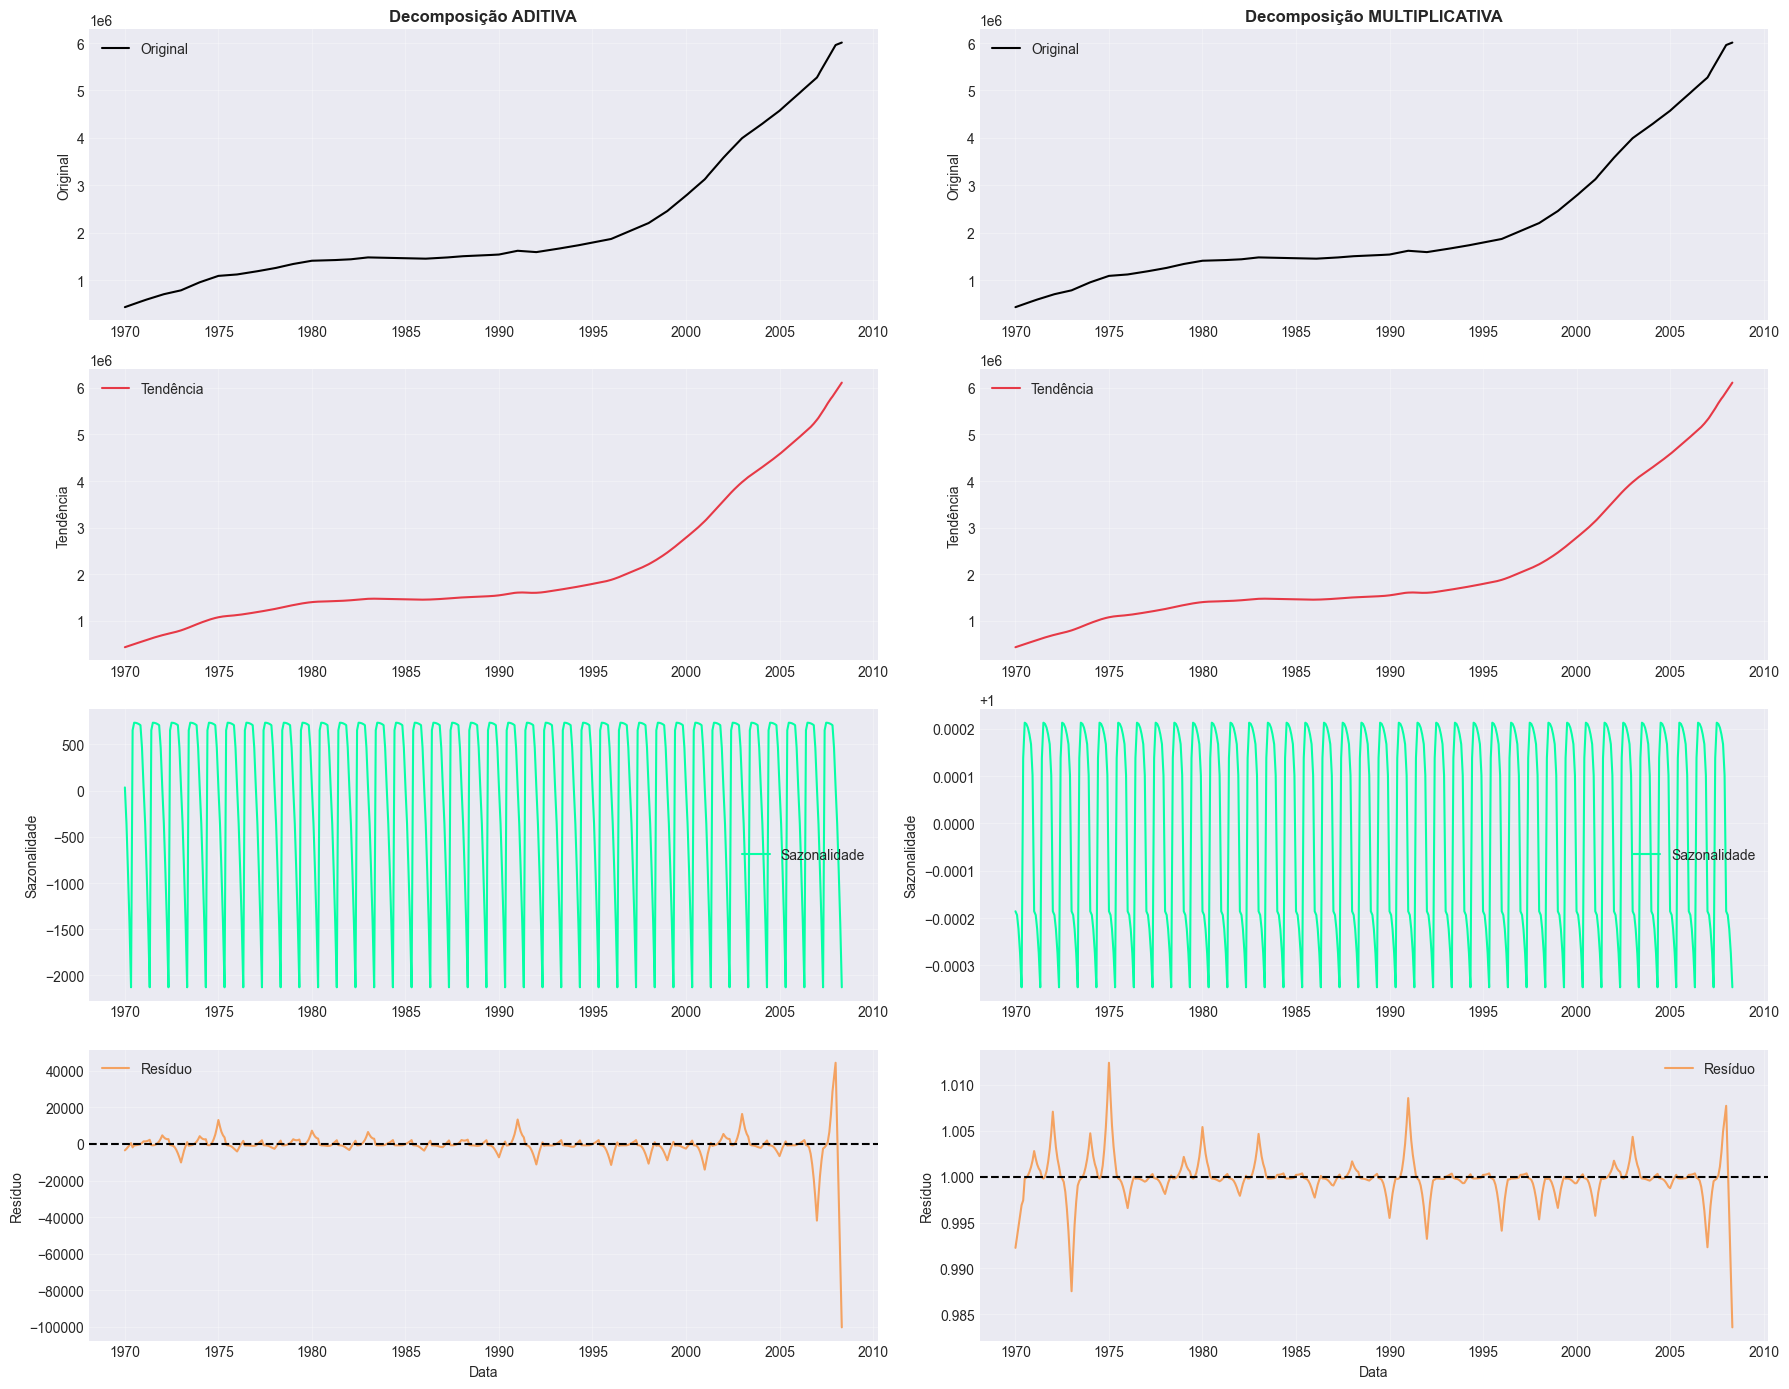

FORÇA DOS COMPONENTES (Aditivo)
Força da Sazonalidade: 0.0145
Força da Tendência: 1.0000



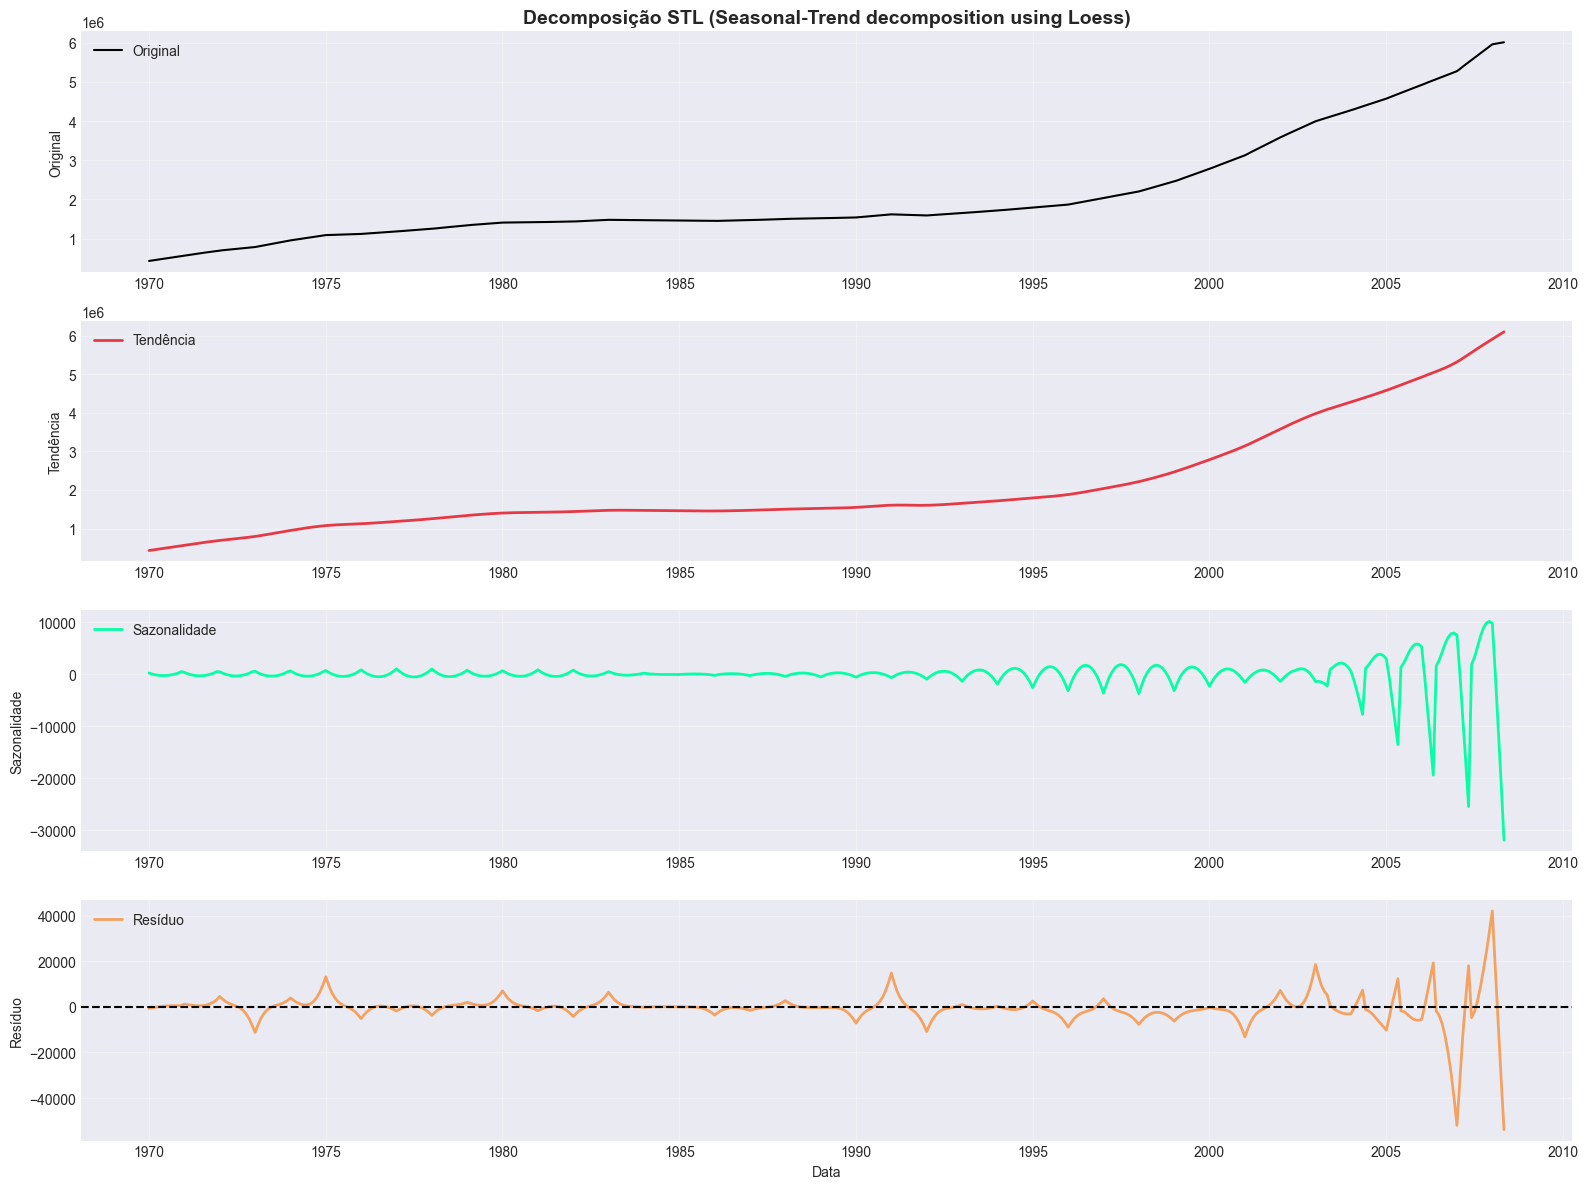


3. TESTES DE ESTACIONARIEDADE

TESTE ADF (Augmented Dickey-Fuller)
--------------------------------------------------
Estatística ADF: 1.397361
P-valor: 0.997102
Lags utilizados: 13
Número de observações: 447
Valores críticos:
  1%: -3.4451
  5%: -2.8680
  10%: -2.5702
Conclusão: Série é NÃO-ESTACIONÁRIA (não rejeita H0)

TESTE KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
--------------------------------------------------
Estatística KPSS: 0.743004
P-valor: 0.010000
Lags utilizados: 12
Valores críticos:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160
Conclusão: Série é NÃO-ESTACIONÁRIA (rejeita H0)

INTERPRETAÇÃO COMBINADA:
Série é NÃO-ESTACIONÁRIA (ambos os testes concordam)



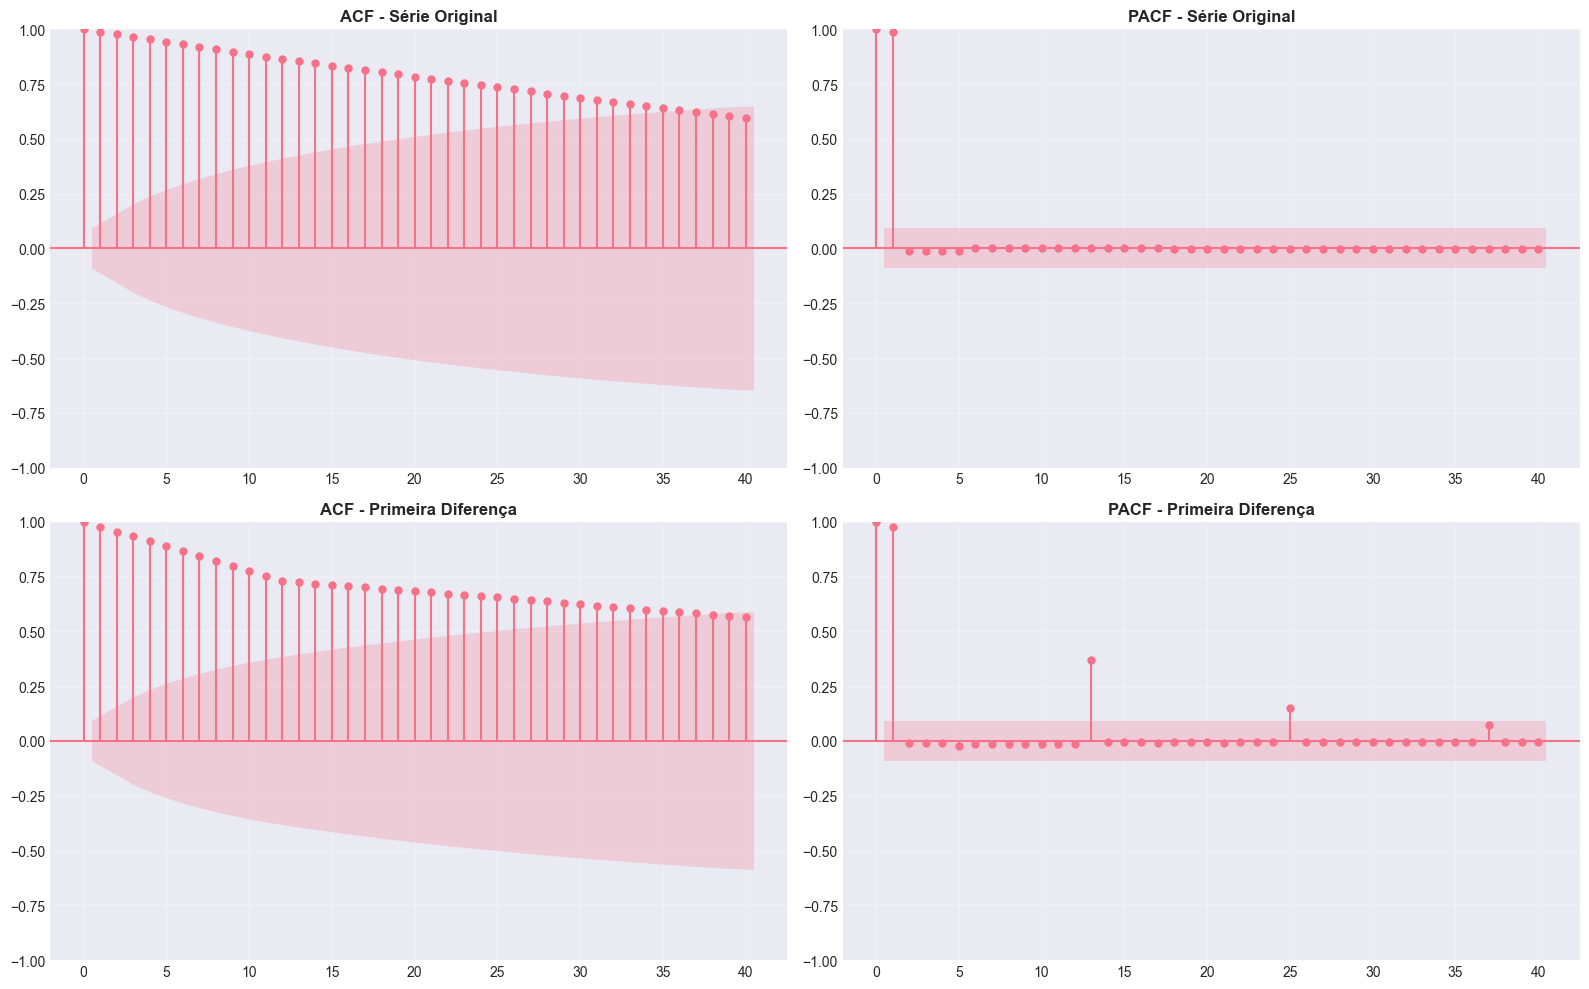


4. AJUSTE E COMPARAÇÃO DE MODELOS

RANDOM FOREST REGRESSOR
--------------------------------------------------
Random Forest treinado com sucesso
  Número de árvores: 200
  Features mais importantes:
    lag_10: 0.0817
    lag_8: 0.0812
    tendencia: 0.0727
    lag_3: 0.0723
    lag_9: 0.0681


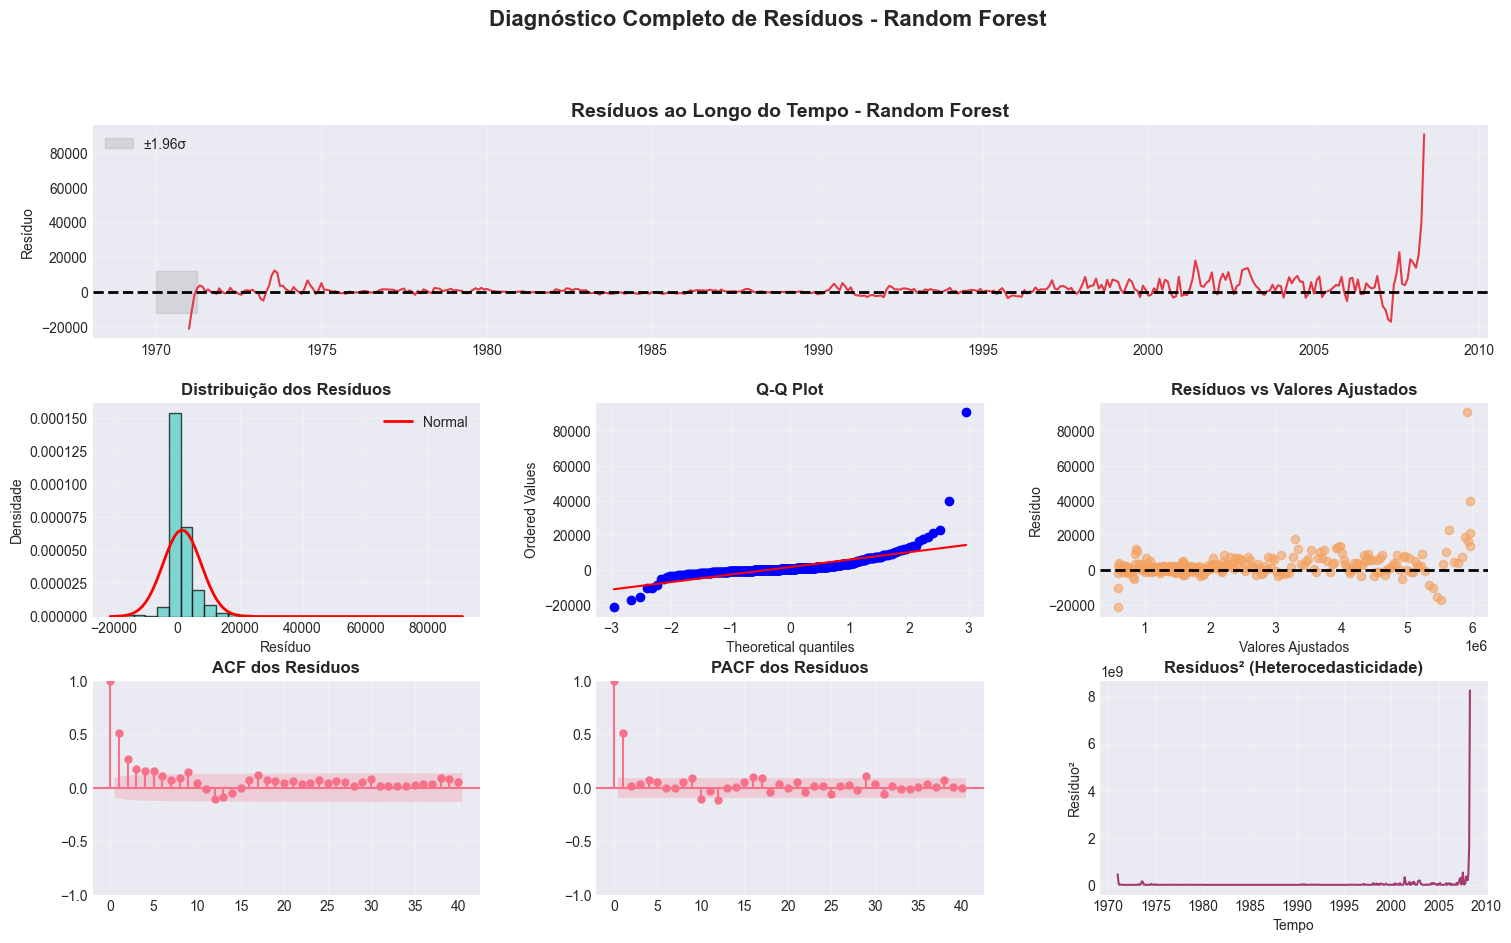


TESTES ESTATÍSTICOS DOS RESÍDUOS - Random Forest
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 210867.9942 | P-valor: 0.0000
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.0000
  ✗ COM autocorrelação

Estatísticas dos Resíduos:
  Média: 1682.962333 (deveria ser ~0)
  Desvio Padrão: 6097.3179
  Assimetria: 7.7509
  Curtose: 106.2290
------------------------------------------------------------

Random Forest ajustado com sucesso

HOLT-WINTERS (SUAVIZAÇÃO EXPONENCIAL)
--------------------------------------------------
✓ Melhor configuração: HW_add_mul
  AIC: 7330.17
  BIC: 7396.30


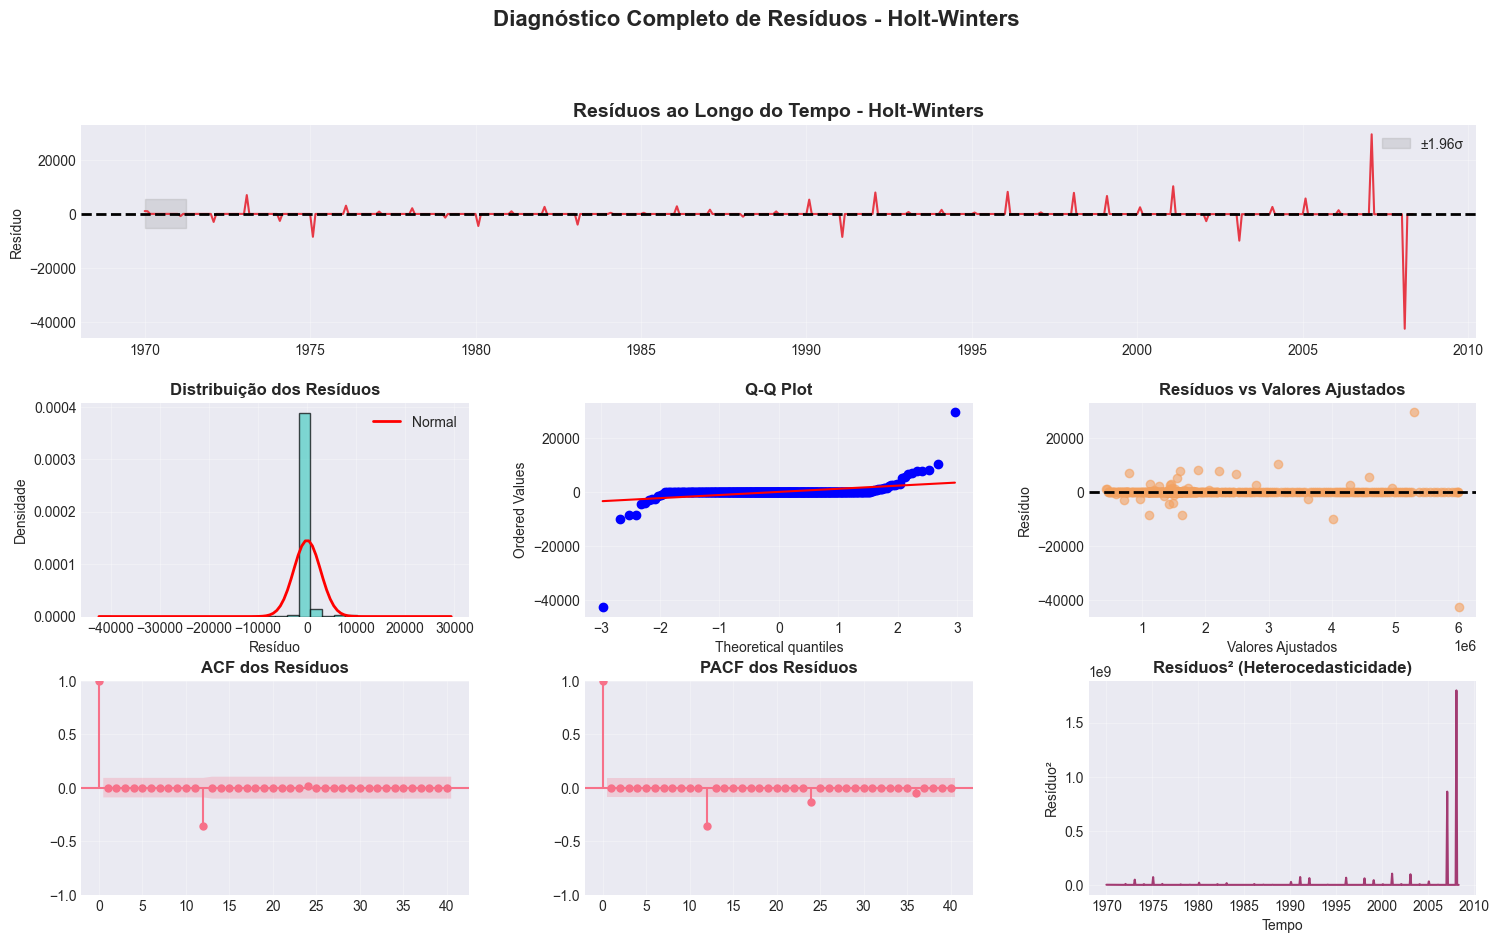


TESTES ESTATÍSTICOS DOS RESÍDUOS - Holt-Winters
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 445541.9115 | P-valor: 0.0000
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.9825
  SEM autocorrelação (Ruído Branco)

Estatísticas dos Resíduos:
  Média: 8.336626 (deveria ser ~0)
  Desvio Padrão: 2742.6041
  Assimetria: -5.2681
  Curtose: 153.6113
------------------------------------------------------------

✓ Holt-Winters ajustado com sucesso

SARIMA (AUTO-ARIMA)
--------------------------------------------------
Buscando melhor modelo SARIMA (pode levar alguns minutos)...
Melhor modelo: ARIMA(0, 2, 0) x (0, 0, 0, 12)[12]
  AIC: 8575.51
  BIC: 8579.64


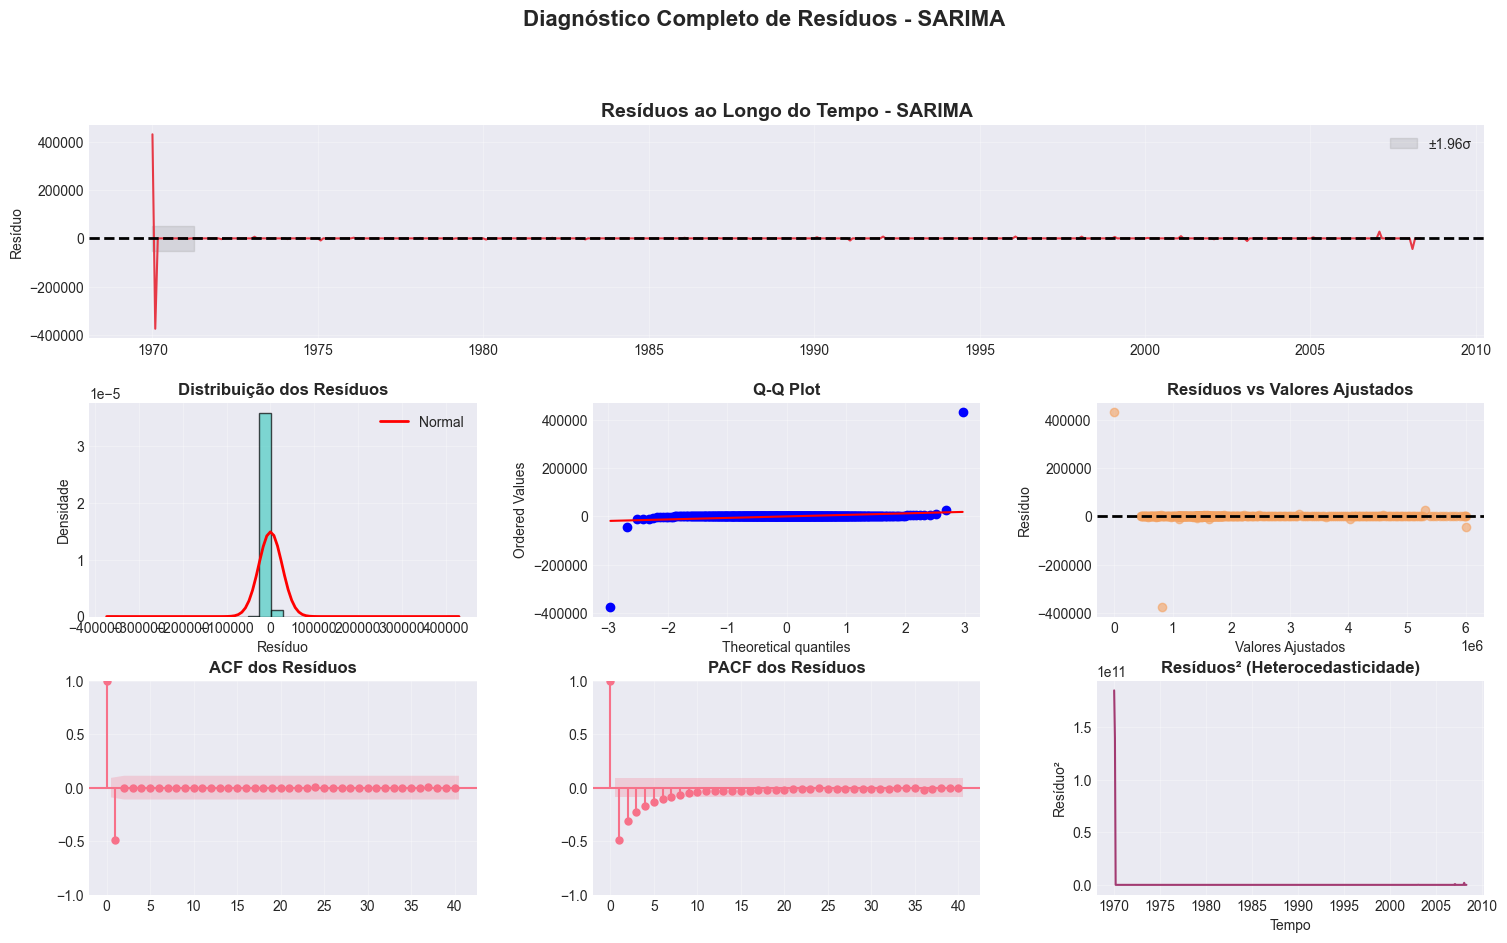

11:03:34 - cmdstanpy - INFO - Chain [1] start processing
11:03:34 - cmdstanpy - INFO - Chain [1] done processing



TESTES ESTATÍSTICOS DOS RESÍDUOS - SARIMA
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 990970.6111 | P-valor: 0.0000
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.0000
  ✗ COM autocorrelação

Estatísticas dos Resíduos:
  Média: 126.206686 (deveria ser ~0)
  Desvio Padrão: 26723.7737
  Assimetria: 3.1285
  Curtose: 229.5452
------------------------------------------------------------

SARIMA ajustado com sucesso

PROPHET
--------------------------------------------------


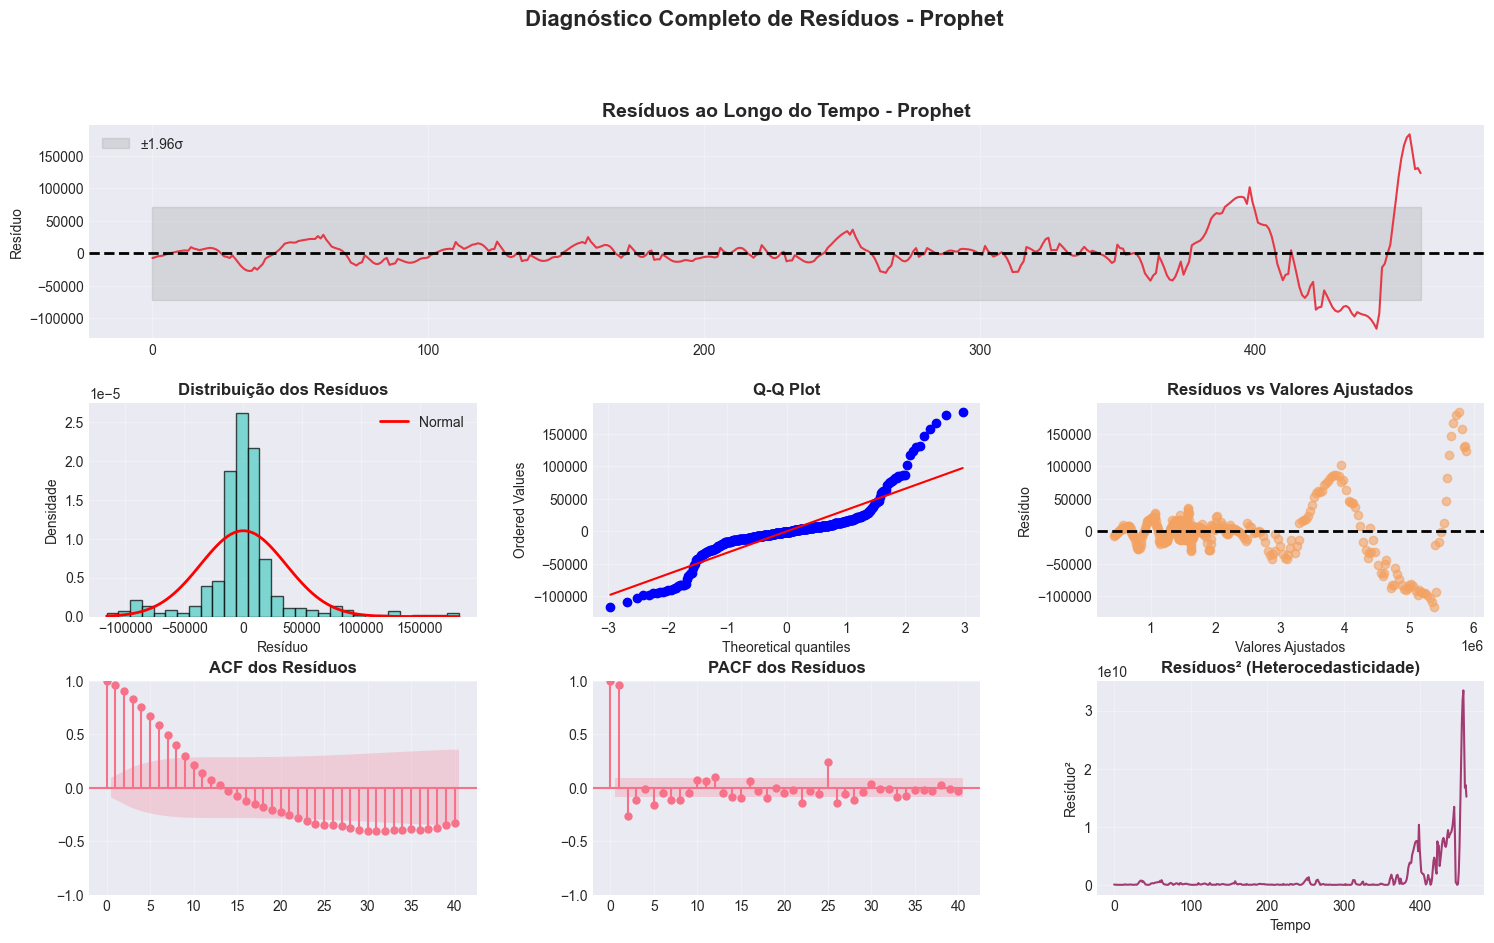


TESTES ESTATÍSTICOS DOS RESÍDUOS - Prophet
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 836.5748 | P-valor: 0.0000
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.0000
  ✗ COM autocorrelação

Estatísticas dos Resíduos:
  Média: 10.390877 (deveria ser ~0)
  Desvio Padrão: 36230.3025
  Assimetria: 0.9540
  Curtose: 6.4017
------------------------------------------------------------



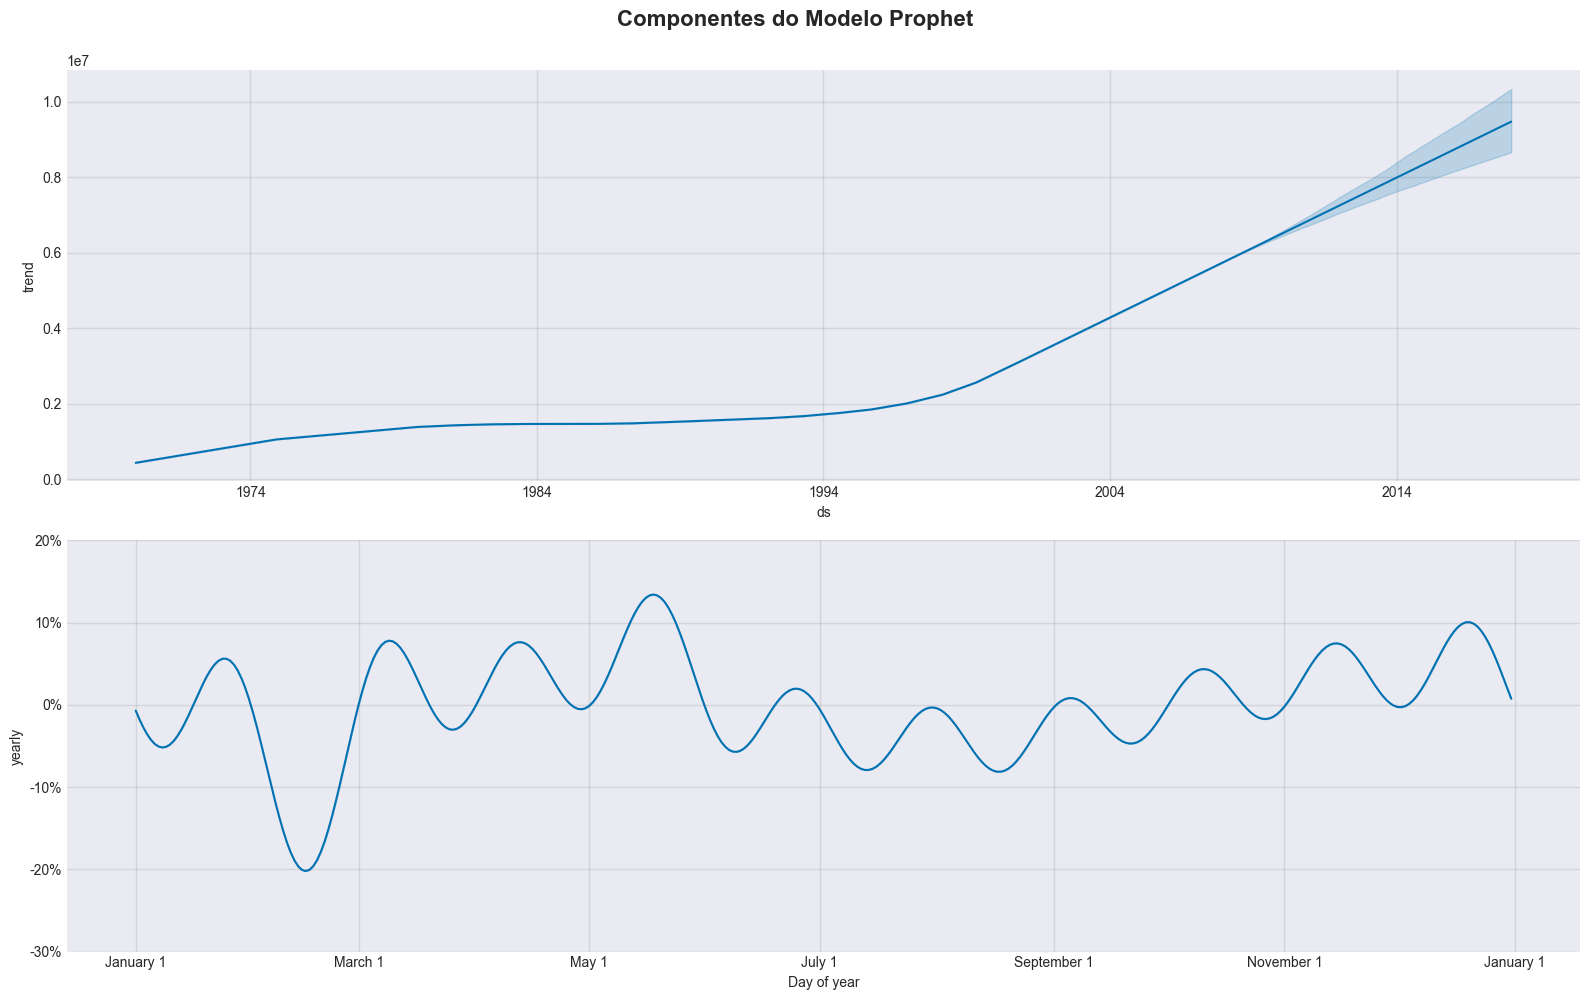

Prophet ajustado com sucesso


5. COMPARAÇÃO VISUAL DOS MODELOS



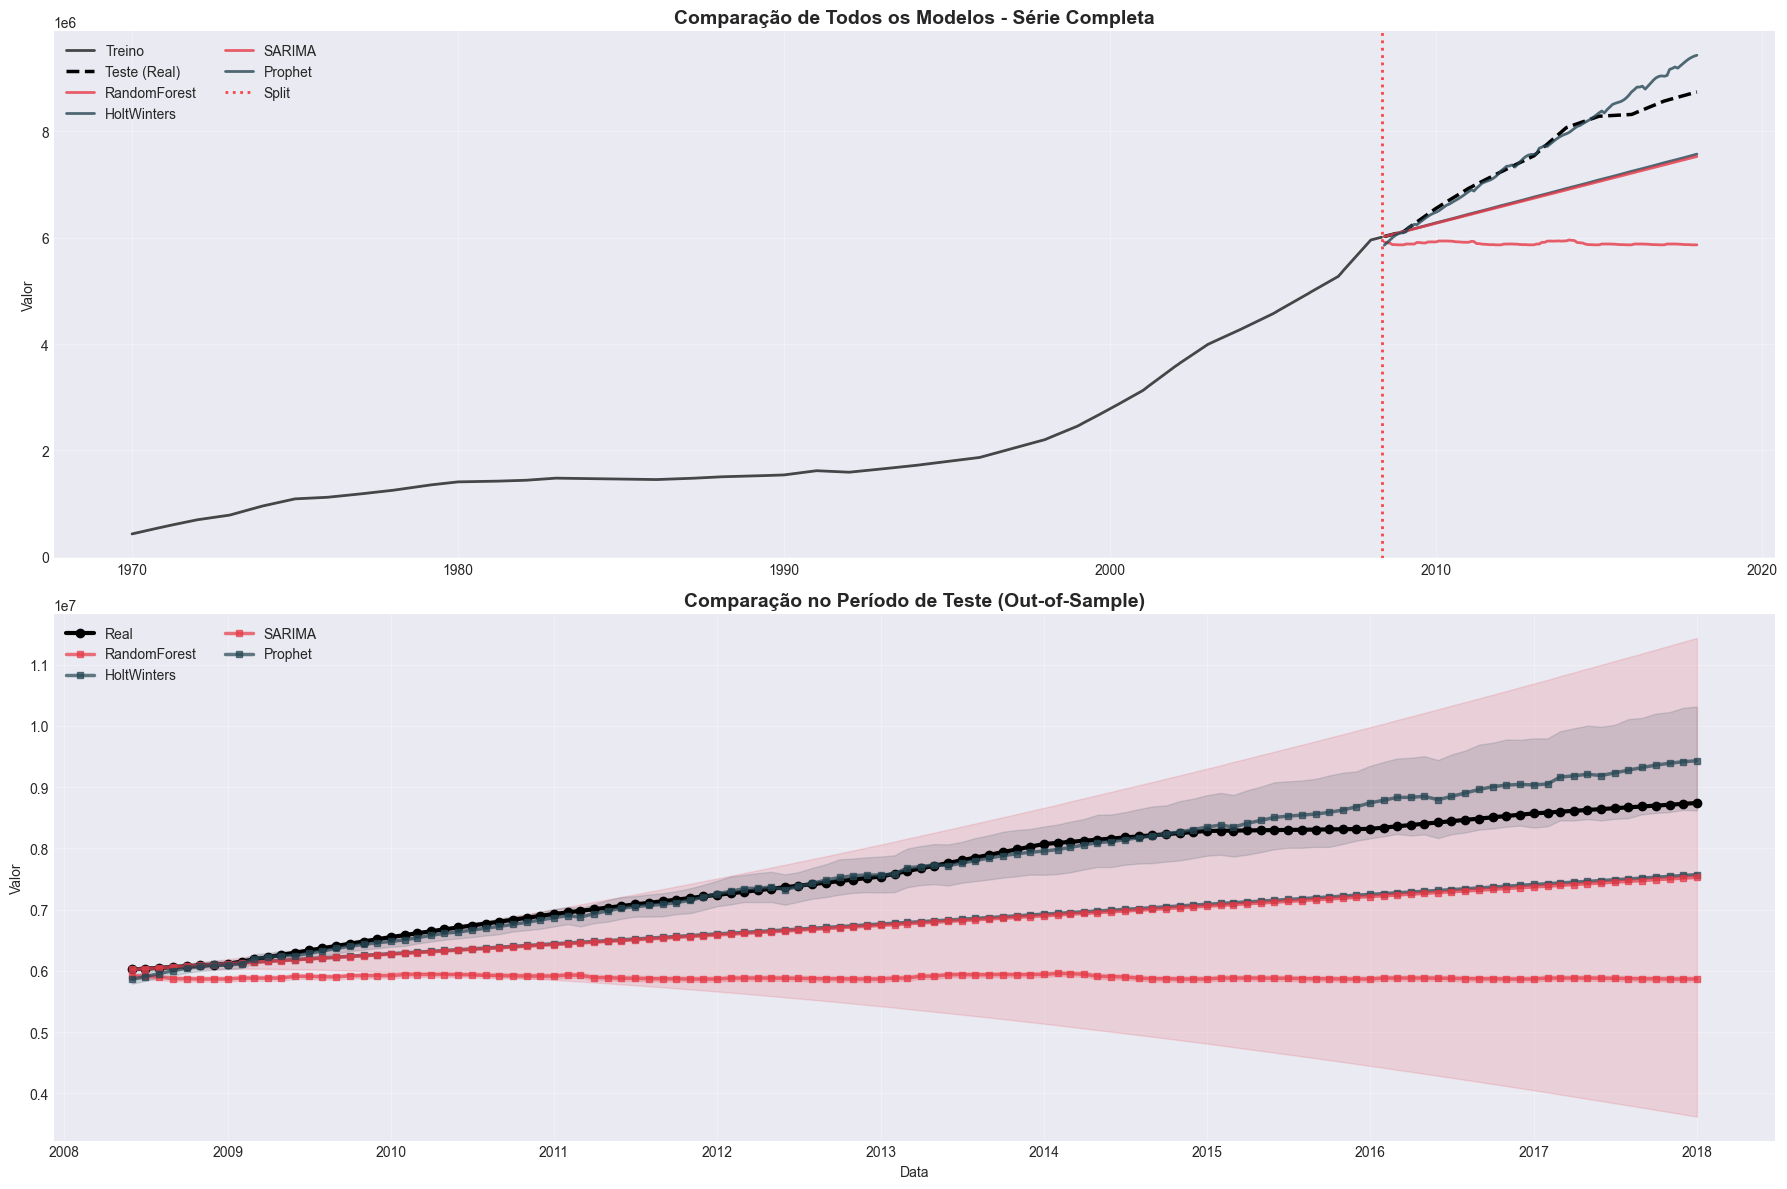


6. RANKING E MÉTRICAS DE PERFORMANCE

TABELA DE MÉTRICAS (ordenada por melhor performance)
                       MAE          RMSE     MAPE    SMAPE      R²  Rank_Médio
Prophet       1.683700e+05  2.626249e+05   2.0608   2.0188  0.9040         1.0
HoltWinters   7.644315e+05  8.667772e+05   9.6038  10.2126 -0.0462         2.0
SARIMA        7.858925e+05  8.913854e+05   9.8718  10.5165 -0.1065         3.0
RandomForest  1.668702e+06  1.875173e+06  21.0176  24.0891 -3.8966         4.0

MELHOR MODELO: Prophet
   MAE: 168369.9529
   RMSE: 262624.9033
   MAPE: 2.06%
   R²: 0.9040


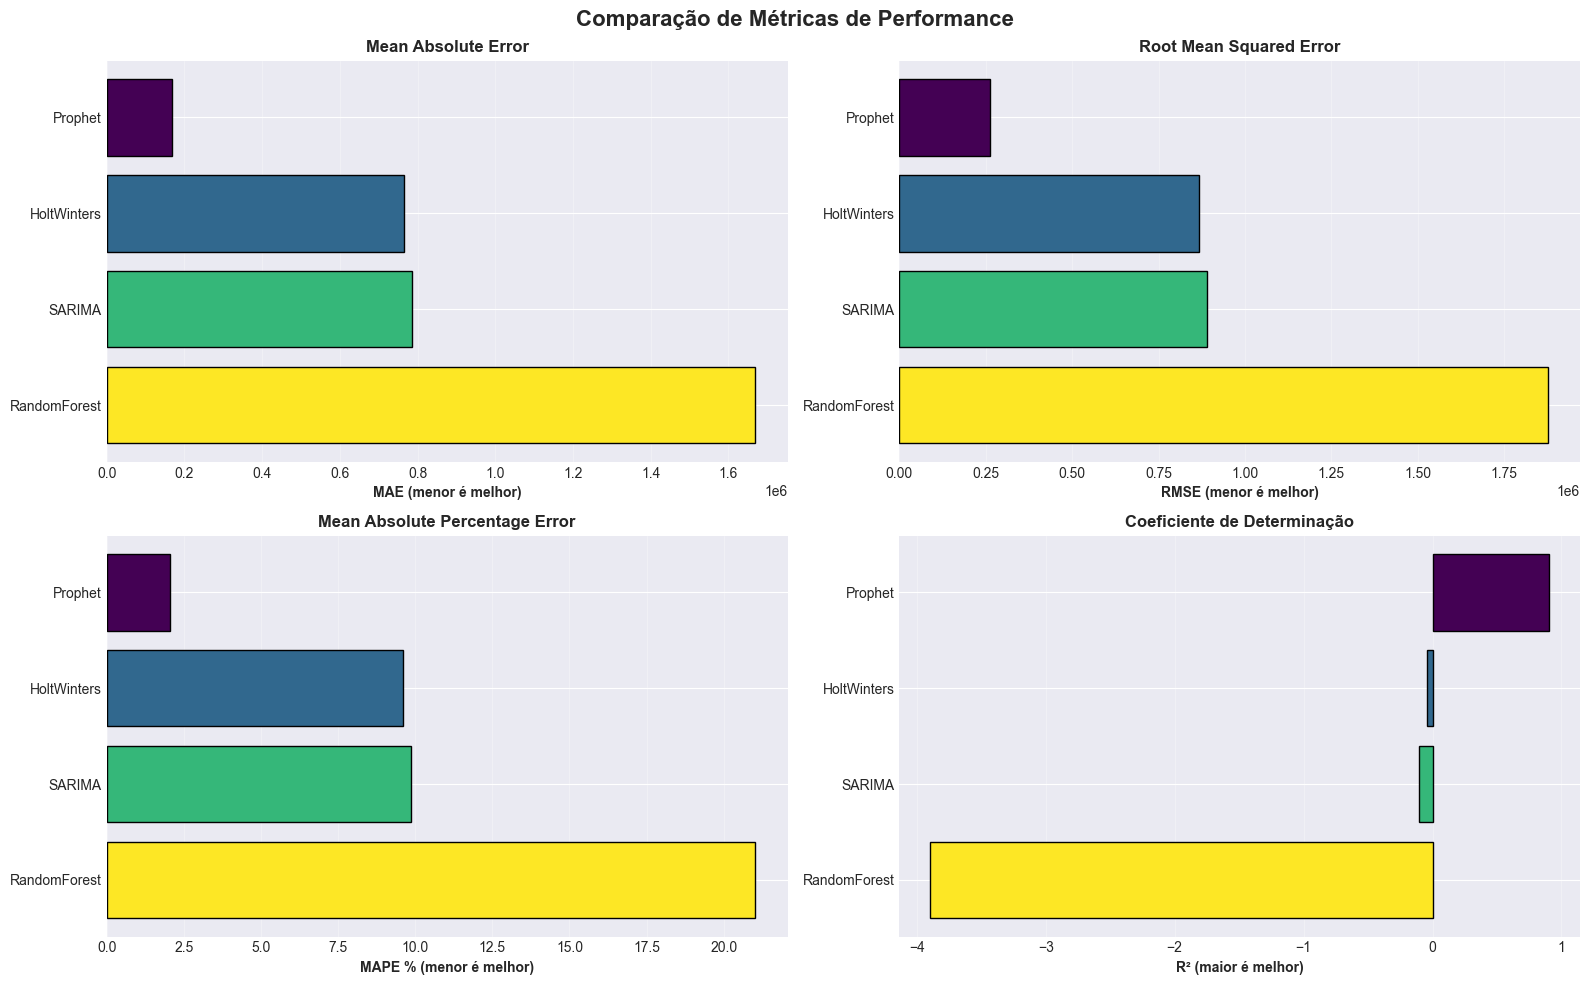


PREVISÃO FUTURA - 12 PERÍODOS À FRENTE

Gerando previsões com Random Forest...
✓ Random Forest concluído
Gerando previsões com Holt-Winters...
✓ Holt-Winters concluído
Gerando previsões com SARIMA...
✓ SARIMA concluído
Gerando previsões com Prophet...
✓ Prophet concluído


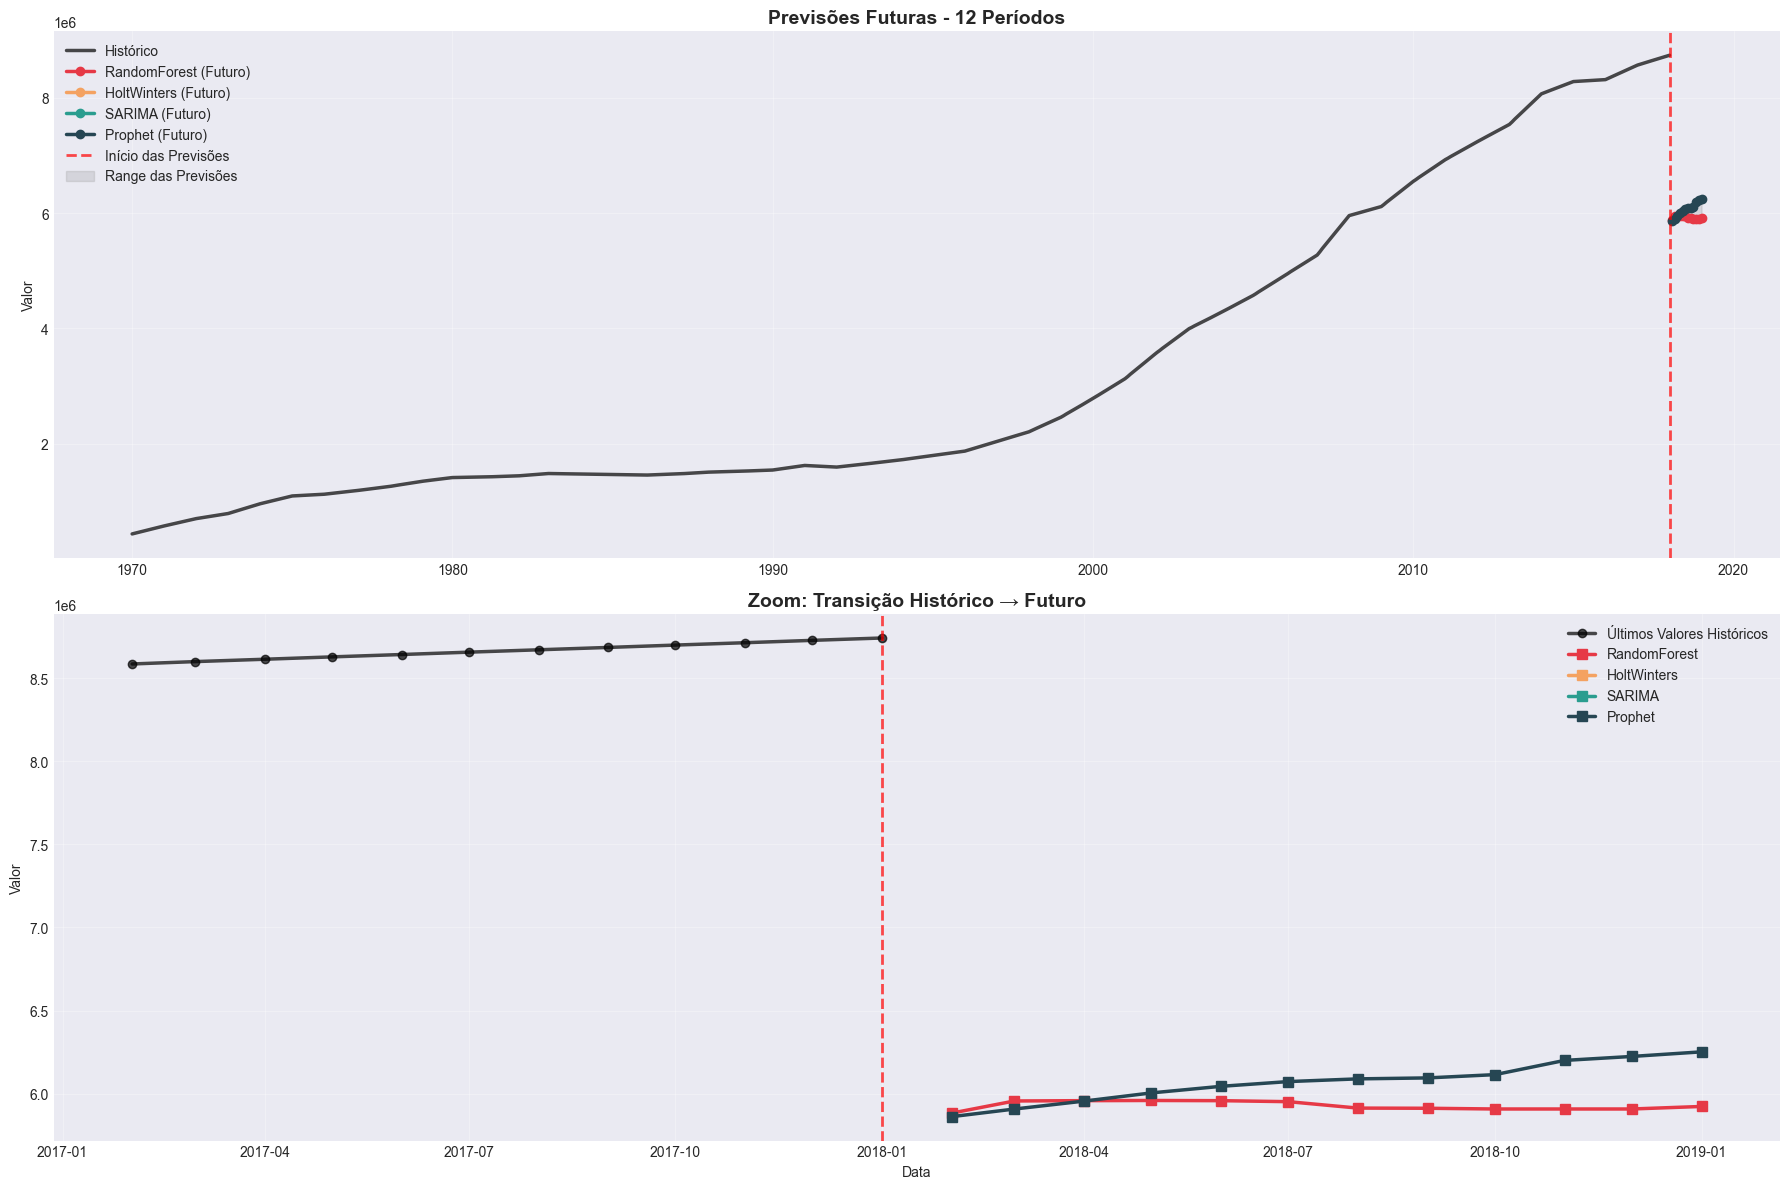


RESUMO DAS PREVISÕES FUTURAS

            RandomForest  HoltWinters  SARIMA     Prophet
2018-02-01    5882604.98          NaN     NaN  5861346.46
2018-03-01    5955737.06          NaN     NaN  5907258.43
2018-04-01    5957601.78          NaN     NaN  5954981.32
2018-05-01    5958665.27          NaN     NaN  6004271.02
2018-06-01    5957511.25          NaN     NaN  6043873.25
2018-07-01    5951461.02          NaN     NaN  6072446.23
2018-08-01    5912805.80          NaN     NaN  6088728.77
2018-09-01    5911806.69          NaN     NaN  6094472.55
2018-10-01    5907440.22          NaN     NaN  6114165.70
2018-11-01    5907440.22          NaN     NaN  6199787.35
2018-12-01    5907440.22          NaN     NaN  6223706.51
2019-01-01    5922706.27          NaN     NaN  6251275.65

Estatísticas por período:
       RandomForest  HoltWinters  SARIMA     Prophet
count         12.00          0.0     0.0       12.00
mean     5927768.40          NaN     NaN  6068026.10
std        26725.19          

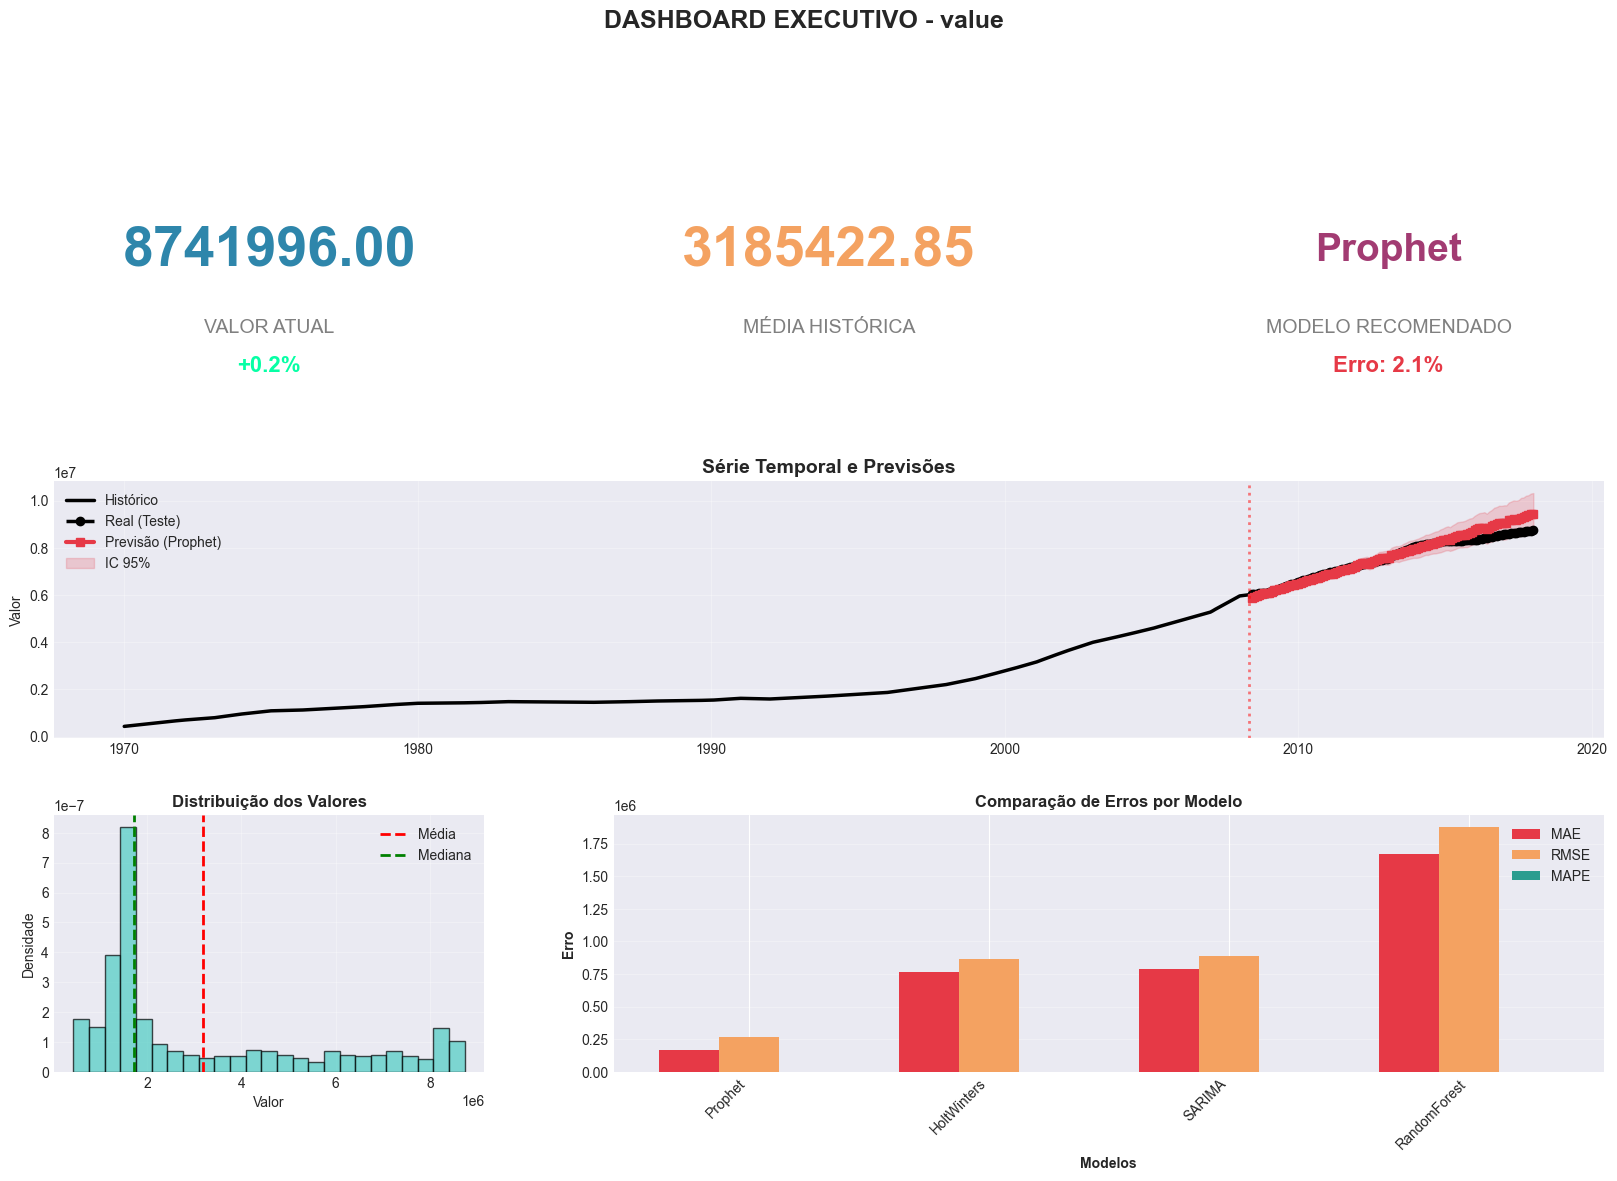


7. RELATÓRIO EXECUTIVO

RESUMO DA ANÁLISE
--------------------------------------------------------------------------------
Variável Analisada: value
Período: 1970-01-01 até 2018-01-01
Total de Observações: 577
Frequência: MS

Tendência Geral: CRESCIMENTO de 1930.8%
Valor Médio: 3185422.85
Volatilidade (CV): 79.3%

🏆 MODELO RECOMENDADO: Prophet
   Precisão: 97.9% (Erro médio: 2.1%)
   Interpretação: O modelo erra em média 2.1% do valor real

PRÓXIMA PREVISÃO: 5861346.46
   Intervalo de Confiança 95%: [5791333.45, 5928983.86]
   Cenário Pessimista: 5791333.45
   Cenário Mais Provável: 5861346.46
   Cenário Otimista: 5928983.86

ANÁLISE COMPLETA FINALIZADA



In [27]:
analisador = AnalisadorSerieTemporalCompleto(
    df=df,
    data_col='date',
    valor_col='value',
    frequencia='MS', 
    test_size=0.2
)
previsoes = analisador.analise_completa()